# SwiftShip Delivery Operations — Exploratory Data Analysis

This notebook analyzes delivery performance, delays, returns, customer segments, shipping modes, and operational factors to identify patterns and generate actionable business insights.

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Load the Cleaned Dataset

Load the cleaned delivery operations dataset prepared during the data cleaning stage.

In [3]:
df = pd.read_csv("../Data/Processed/delivery_operations_clean.csv")

## 2. Dataset Overview

Review the dimensions, columns, and delivery status categories of the cleaned dataset before beginning the business analysis.

In [4]:
df.shape

(23698, 24)

In [5]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_segment',
       'customer_city', 'warehouse_id', 'warehouse_city', 'product_category',
       'quantity', 'order_value', 'delivery_partner', 'vehicle_type',
       'shipping_mode', 'distance_km', 'package_weight_kg',
       'promised_delivery_date', 'dispatch_date', 'delivery_date',
       'delivery_status', 'delay_days', 'weather_condition', 'return_flag',
       'return_reason', 'customer_rating'],
      dtype='str')

In [6]:
df["delivery_status"].unique()

<StringArray>
['Delayed', 'Delivered', 'Failed']
Length: 3, dtype: str

## 3. Delivery Partner Performance

### Business Question

**Which delivery partner has the highest delay rate?**

In [7]:
delayed_rate = pd.crosstab(df["delivery_partner"],df["delivery_status"]).reset_index()
delayed_rate.columns.name = None
delayed_rate

,delivery_partner,Delayed,Delivered,Failed
0,BlueDartX,964,2855,61
1,FastTrack,2370,1576,88
2,MetroShip,2593,1377,73
3,ParcelPro,1834,1958,80
4,QuickRoute,3435,434,80
5,SwiftGo,2893,838,70
6,Unknown,73,44,2


In [8]:
delayed_rate["Total"] = delayed_rate["Delayed"] + delayed_rate["Delivered"] + delayed_rate["Failed"]
delayed_rate["Delayed Rate"] = (delayed_rate["Delayed"] / delayed_rate["Total"]) * 100 
delayed_rate

,delivery_partner,Delayed,Delivered,Failed,Total,Delayed Rate
0,BlueDartX,964,2855,61,3880,24.845361
1,FastTrack,2370,1576,88,4034,58.750620
2,MetroShip,2593,1377,73,4043,64.135543
3,ParcelPro,1834,1958,80,3872,47.365702
4,QuickRoute,3435,434,80,3949,86.984047
5,SwiftGo,2893,838,70,3801,76.111550
6,Unknown,73,44,2,119,61.344538


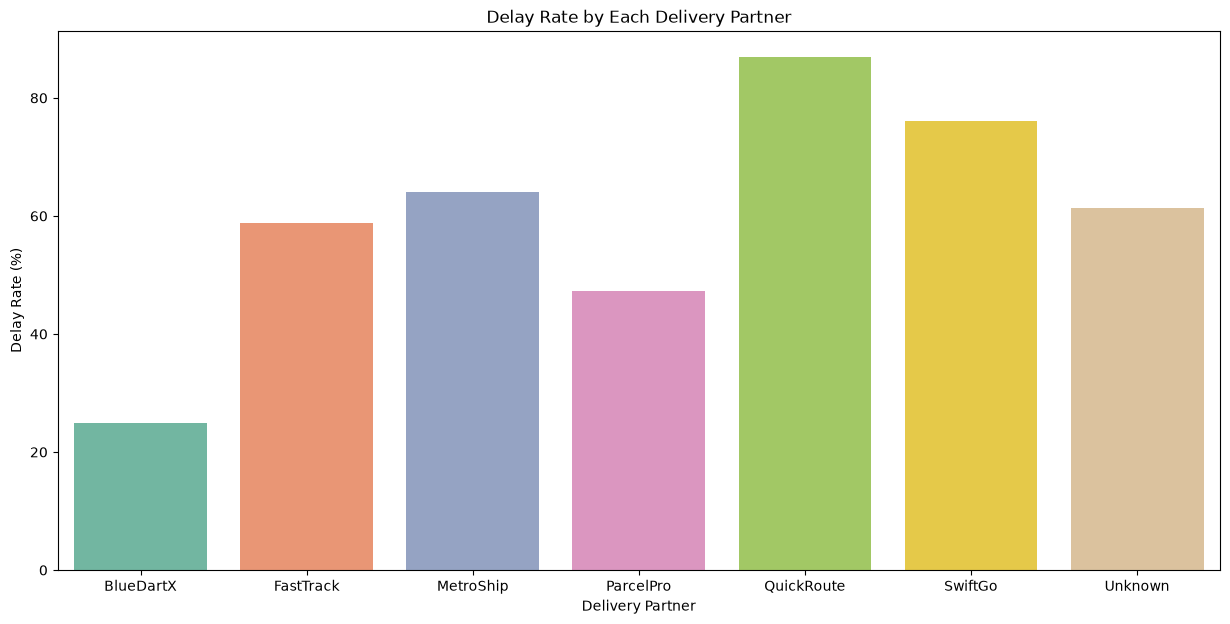

In [9]:
plt.figure(figsize=(15,7))

sns.barplot(x = "delivery_partner", y = "Delayed Rate", data = delayed_rate,hue="delivery_partner",palette="Set2",legend=False)
plt.title("Delay Rate by Each Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Delay Rate (%)")
plt.show()

### Recommendation

The delivery partner with the highest delay rate should be investigated further to identify operational issues such as dispatch delays, route efficiency, vehicle availability, or service-level problems.

## 4. Weather Conditions and Delivery Delays

### Business Question

**Which weather condition has the highest delay rate?**

Compare delay rates across different weather conditions to determine whether certain conditions are associated with higher delivery delays.

In [10]:
df["weather_condition"].unique() 

<StringArray>
['Clear', 'Rain', 'Cloudy', 'Storm', 'Unknown']
Length: 5, dtype: str

In [11]:
Weather = pd.crosstab(df["weather_condition"],df["delivery_status"]).reset_index()
Weather.columns.name = None
Weather

,weather_condition,Delayed,Delivered,Failed
0,Clear,6498,6097,247
1,Cloudy,3093,1977,92
2,Rain,3409,875,80
3,Storm,1075,79,33
4,Unknown,87,54,2


In [12]:
Weather["Total"] = Weather["Delayed"] + Weather["Delivered"] + Weather["Failed"]
Weather["Delay Rate"] = (Weather["Delayed"] / Weather["Total"]) * 100
Weather

,weather_condition,Delayed,Delivered,Failed,Total,Delay Rate
0,Clear,6498,6097,247,12842,50.599595
1,Cloudy,3093,1977,92,5162,59.918636
2,Rain,3409,875,80,4364,78.116407
3,Storm,1075,79,33,1187,90.564448
4,Unknown,87,54,2,143,60.839161


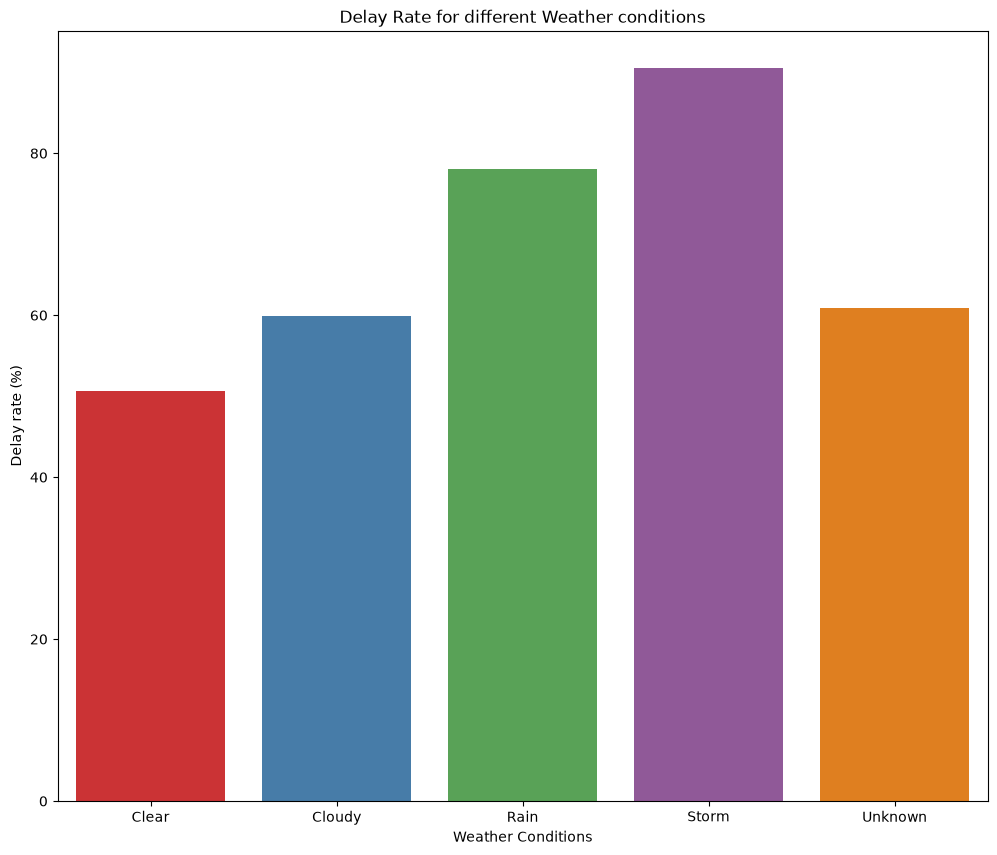

In [13]:
plt.figure(figsize=(12,10))

sns.barplot(x="weather_condition",y="Delay Rate",data=Weather,hue="weather_condition",palette= "Set1",legend=False)
plt.xlabel("Weather Conditions")
plt.ylabel("Delay rate (%)")
plt.title("Delay Rate for different Weather conditions")
plt.show()

## 5. Order Distribution by Customer City

### Business Question

**Which customer cities generate the highest number of orders?**

Compare the total number of orders across customer cities to identify the locations with the highest order volume.

In [14]:
df["customer_city"].unique()

<StringArray>
['Ahmedabad',      'Pune',     'Delhi', 'Hyderabad', 'Bengaluru',   'Chennai',
    'Mumbai',   'Kolkata']
Length: 8, dtype: str

In [15]:
orders_by_city = df.groupby("customer_city")["order_id"].count().reset_index()
orders_by_city.rename(columns={"order_id": "Total Orders"}, inplace=True)
orders_by_city

,customer_city,Total Orders
0,Ahmedabad,2987
1,Bengaluru,2988
2,Chennai,2956
3,Delhi,2896
4,Hyderabad,2962
5,Kolkata,3002
6,Mumbai,2940
7,Pune,2967


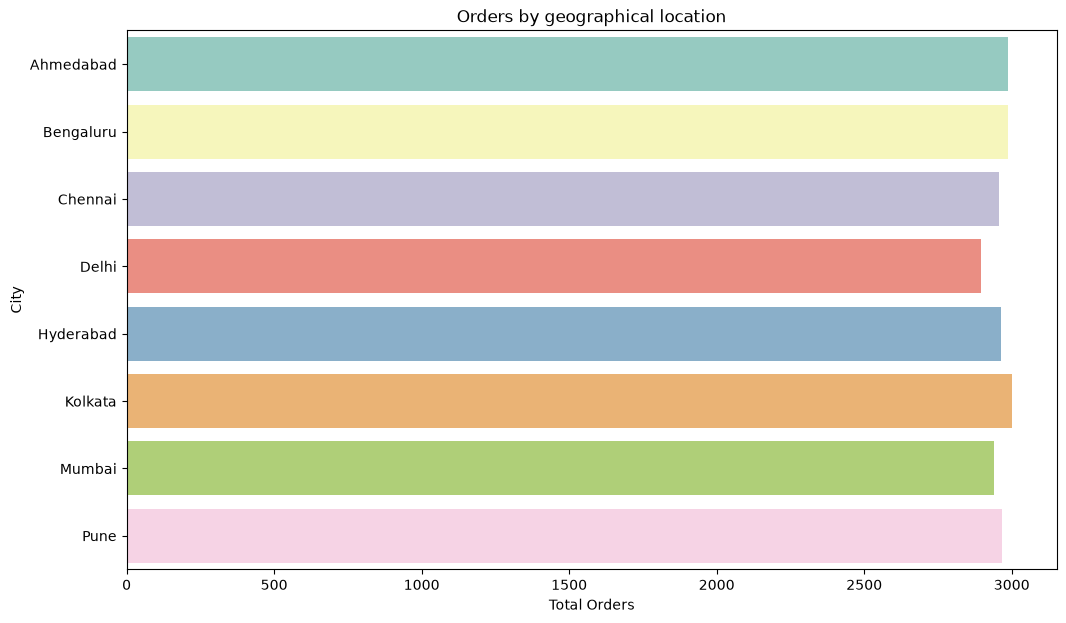

In [16]:
plt.figure(figsize=(12,7))

sns.barplot(x = "Total Orders", y="customer_city",data=orders_by_city,hue="customer_city",palette = "Set3", legend = False)
plt.xlabel("Total Orders")
plt.ylabel("City")
plt.title("Orders by geographical location")
plt.show()

## 6. Product Category Return Analysis

### Business Question

**How do returned and non-returned orders compare across product categories?**

Calculate the return and non-return percentages for each product category and compare them using a grouped bar chart.

In [17]:
df["product_category"].unique()

<StringArray>
['Grocery', 'Office Supplies', 'Electronics', 'Clothing', 'Furniture']
Length: 5, dtype: str

In [18]:
Product_return_rate = pd.crosstab(df["product_category"],df["return_flag"]).reset_index()
Product_return_rate.columns.name= None
Product_return_rate.rename(columns={1:"Returned",0:"Not Returned"},inplace=True)
Product_return_rate


,product_category,Not Returned,Returned
0,Clothing,4018,255
1,Electronics,4856,316
2,Furniture,3959,249
3,Grocery,3760,262
4,Office Supplies,5624,399


In [19]:
Product_return_rate["Total"] = Product_return_rate["Not Returned"] + Product_return_rate["Returned"]
Product_return_rate["Return Rate"] = (Product_return_rate["Returned"] / Product_return_rate["Total"]) * 100
Product_return_rate["Not Returned Rate"] = (Product_return_rate["Not Returned"] / Product_return_rate["Total"]) * 100
Product_return_rate

,product_category,Not Returned,Returned,Total,Return Rate,Not Returned Rate
0,Clothing,4018,255,4273,5.967704,94.032296
1,Electronics,4856,316,5172,6.109822,93.890178
2,Furniture,3959,249,4208,5.917300,94.082700
3,Grocery,3760,262,4022,6.514172,93.485828
4,Office Supplies,5624,399,6023,6.624606,93.375394


<Figure size 2000x2000 with 0 Axes>

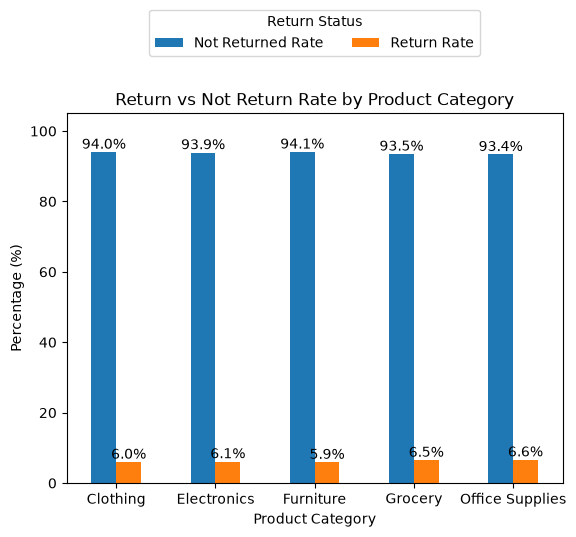

In [20]:
plt.figure(figsize=(20,20))

ax = Product_return_rate.plot(x="product_category", y =["Not Returned Rate","Return Rate"],kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

ax.set_title("Return vs Not Return Rate by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Percentage (%)")

ax.legend(title="Return Status",loc="upper center",bbox_to_anchor=(0.5, 1.30),ncol=2)

plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.show()

## 7. Shipping Mode and Delivery Delays

### Business Question

**Does shipping mode affect delivery delays?**

Compare the delay rate across different shipping modes to evaluate whether faster shipping options are associated with better delivery performance.

In [21]:
df["shipping_mode"].unique()

<StringArray>
['Standard', 'Same Day', 'Express']
Length: 3, dtype: str

In [22]:
shipping_rate = pd.crosstab(df["shipping_mode"],df["delivery_status"]).reset_index()
shipping_rate.columns.name =  None
shipping_rate["Total"] = shipping_rate["Delayed"] + shipping_rate["Delivered"] + shipping_rate["Failed"]
shipping_rate["Delayed Rate"] = (shipping_rate["Delayed"] / shipping_rate["Total"]) * 100
shipping_rate

,shipping_mode,Delayed,Delivered,Failed,Total,Delayed Rate
0,Express,3512,2266,92,5870,59.829642
1,Same Day,951,592,33,1576,60.342640
2,Standard,9699,6224,329,16252,59.678809


Text(0.5, 1.0, 'Delayed rate foe each shipping mode ')

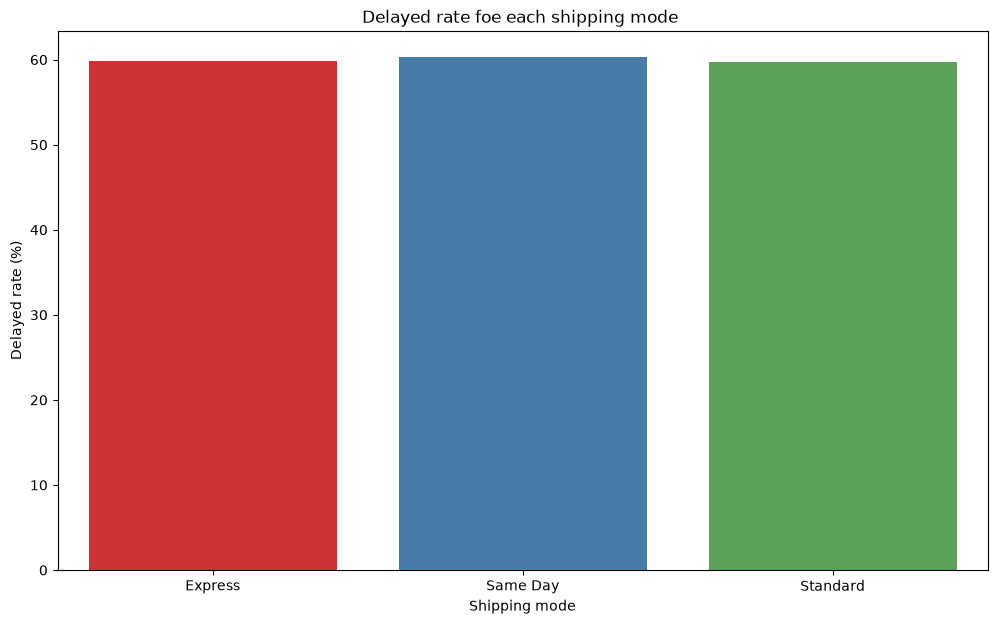

In [23]:
plt.figure(figsize=(12,7))
sns.barplot(x="shipping_mode",y="Delayed Rate",data=shipping_rate,hue="shipping_mode",palette="Set1",legend=False)
plt.xlabel("Shipping mode")
plt.ylabel("Delayed rate (%)")
plt.title("Delayed rate foe each shipping mode ")


In [24]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23698 entries, 0 to 23697
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                23698 non-null  str           
 1   order_date              23698 non-null  datetime64[us]
 2   customer_id             23698 non-null  str           
 3   customer_segment        23698 non-null  str           
 4   customer_city           23698 non-null  str           
 5   warehouse_id            23698 non-null  str           
 6   warehouse_city          23698 non-null  str           
 7   product_category        23698 non-null  str           
 8   quantity                23698 non-null  int64         
 9   order_value             23698 non-null  float64       
 10  delivery_partner        23698 non-null  str           
 11  vehicle_type            23698 non-null  str           
 12  shipping_mode           23698 non-null  str           
 1

In [26]:
df["delivery_time"] = df["delivery_date"] - df["order_date"]
df["delivery_time"].head()

0   6 days
1   7 days
2   6 days
3   4 days
4   8 days
Name: delivery_time, dtype: timedelta64[us]

## 8. Delivery Time by Shipping Mode

### Business Question

**What is the average delivery time for each shipping mode?**

Calculate the actual delivery time from order date to delivery date and compare the average delivery time across shipping modes.

In [27]:
average_delivery_time  = df.groupby("shipping_mode")["delivery_time"].mean().reset_index()
average_delivery_time["delivery_time"] = average_delivery_time["delivery_time"].dt.days
average_delivery_time.rename(columns={"delivery_time":"Avg_delivery_time"},inplace=True)
average_delivery_time

,shipping_mode,Avg_delivery_time
0,Express,4
1,Same Day,3
2,Standard,6


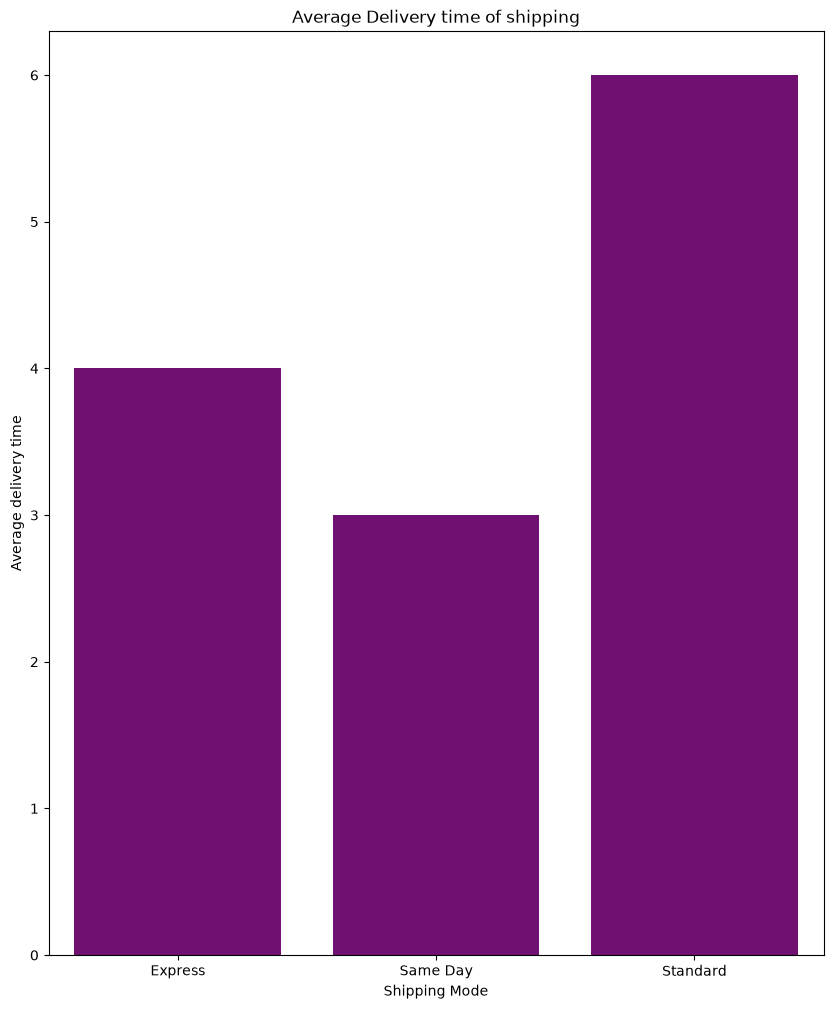

In [28]:
plt.figure(figsize=(10,12))


sns.barplot(x = "shipping_mode",y="Avg_delivery_time",data=average_delivery_time,color="purple")
plt.xlabel("Shipping Mode")
plt.ylabel("Average delivery time")
plt.title("Average Delivery time of shipping")
plt.show()

## 9. Customer Segment Return Analysis

### Business Question

**Which customer segment has the highest return rate?**

Compare return rates across Consumer, Corporate, and Home Office customer segments.

In [34]:
customer_segement_rate = pd.crosstab(df["customer_segment"],df["return_flag"]).reset_index()
customer_segement_rate.columns.name= None
customer_segement_rate.rename(columns={1:"Returned",0:"Not Returned"},inplace=True)
customer_segement_rate["Total"] = customer_segement_rate["Not Returned"]+ customer_segement_rate["Returned"]
customer_segement_rate["Return Rate"] = (customer_segement_rate["Returned"] / customer_segement_rate["Total"]) * 100
customer_segement_rate

,customer_segment,Not Returned,Returned,Total,Return Rate
0,Consumer,13605,926,14531,6.372583
1,Corporate,5134,318,5452,5.832722
2,Home Office,3301,226,3527,6.407712
3,Unknown,177,11,188,5.851064


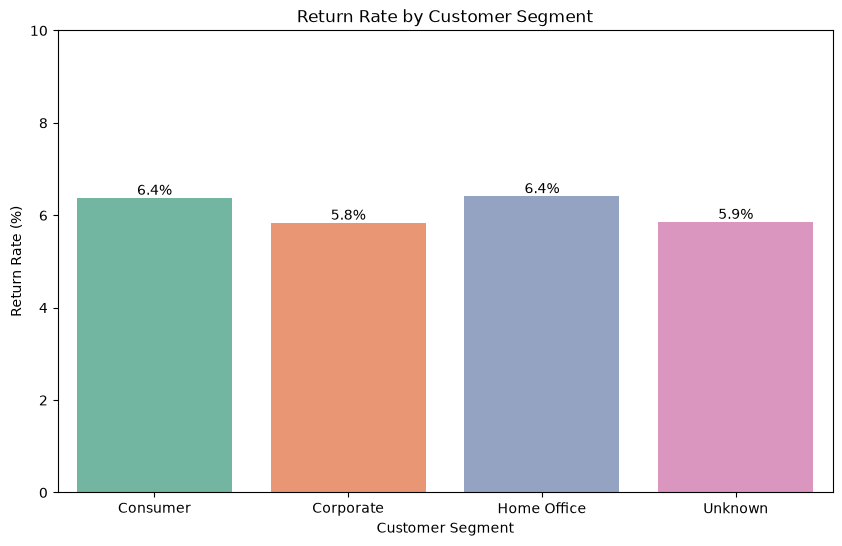

In [35]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x="customer_segment",y="Return Rate",data=customer_segement_rate,hue="customer_segment",palette="Set2",legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Return Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Return Rate (%)")
plt.ylim(0, 10)

plt.show()

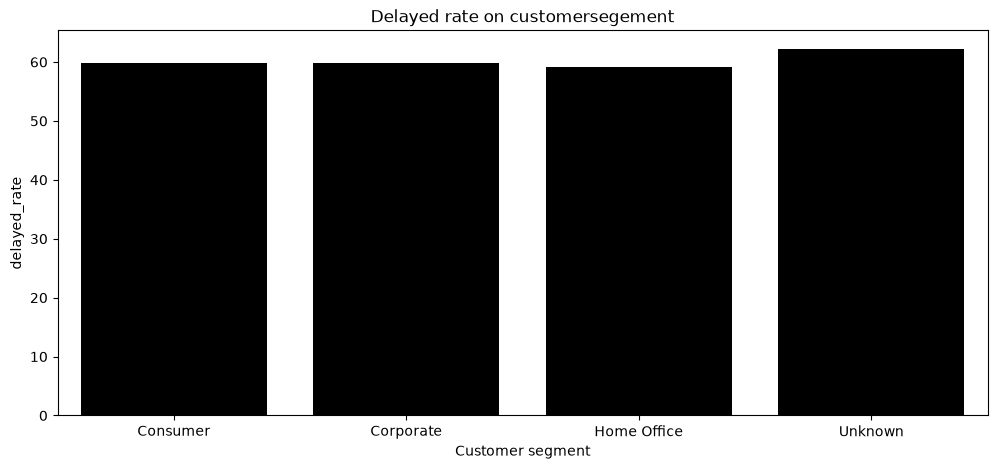

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(x = "customer_segment", y = "Delayed Rate",data=customer_segement_rate,color="black")
plt.xlabel("Customer segment")
plt.ylabel("delayed_rate")
plt.title("Delayed rate on customersegement")
plt.show()

## 10. Relationship Between Operational Factors and Delays

### Business Question

**Do distance, package weight, order value, or quantity have a relationship with delivery delays?**



In [ ]:
corr_cols = ["distance_km", "package_weight_kg", "delay_days", "order_value", "quantity"]
correlation = df[corr_cols].corr()
correlation


,distance_km,package_weight_kg,delay_days,order_value,quantity
distance_km,1.000000,-0.007636,0.187228,-0.011145,-0.008160
package_weight_kg,-0.007636,1.000000,0.003483,-0.012788,-0.011733
delay_days,0.187228,0.003483,1.000000,0.005741,0.012147
order_value,-0.011145,-0.012788,0.005741,1.000000,0.568575
quantity,-0.008160,-0.011733,0.012147,0.568575,1.000000


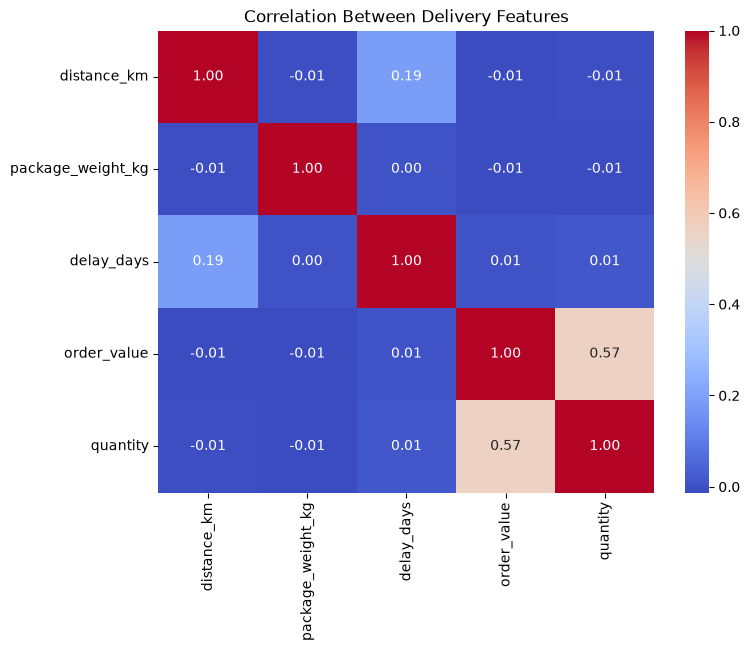

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Delivery Features")
plt.show()

In [36]:
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'customer_segment',
 'customer_city',
 'warehouse_id',
 'warehouse_city',
 'product_category',
 'quantity',
 'order_value',
 'delivery_partner',
 'vehicle_type',
 'shipping_mode',
 'distance_km',
 'package_weight_kg',
 'promised_delivery_date',
 'dispatch_date',
 'delivery_date',
 'delivery_status',
 'delay_days',
 'weather_condition',
 'return_flag',
 'return_reason',
 'customer_rating',
 'delivery_time']

## 11. Key Findings and Business Recommendations

### Key Findings

Summarize the major patterns identified from delivery partner performance, weather conditions, customer locations, product returns, shipping modes, customer segments, and operational factors.

### Business Recommendations

Translate the key findings into practical recommendations for improving delivery performance, reducing delays and returns, and improving customer experience.